In [6]:
from pathlib import Path
import os

import pandas as pd

root_dir = Path(os.getcwd()).parent
processed_dir = root_dir / "data" / "processed"
primary_csv = processed_dir / "balanced_veremi_dataset.csv"

if not primary_csv.exists():
    print("Processed files:")
    for path in sorted(processed_dir.glob("*")):
        print(f"- {path}")
    raise FileNotFoundError(
        "balanced_veremi_dataset.csv not found in data/processed"
    )

df = pd.read_csv(primary_csv)
print("Columns:")
for column_name in df.columns:
    print(f"- {column_name}")


Columns:
- rcvTime
- pos_0
- pos_1
- pos_noise_0
- pos_noise_1
- spd_0
- spd_1
- spd_noise_0
- spd_noise_1
- acl_0
- acl_1
- acl_noise_0
- acl_noise_1
- hed_0
- hed_1
- hed_noise_0
- hed_noise_1
- ReceiverID
- AttackerType


## Column Summary (CAV Security Context)

- `sender_id` / `receiver_id` / `vehicle_id`: Unique identifiers for vehicles or message endpoints used to build trajectories and cross-check message sources.
- `timestamp` / `time` / `secMark`: Message time used to order BSMs and compute kinematic consistency.
- `posX`, `posY`, `posZ`: Vehicle position in a global frame used for trajectory reconstruction and distance checks.
- `vX`, `vY`, `vZ`: Velocity components used to validate motion against reported positions.
- `accelX`, `accelY`, `accelZ`: Acceleration components used to enforce physical limits.
- `heading` / `yaw` / `yawRate`: Orientation or turn rate used to check motion plausibility.
- `RSSI`: Signal strength used to cross-check claimed positions with radio behavior.
- `AttackerType` / `AttackType` / `Label`: Ground-truth class label used to evaluate attack categories and benign traffic.

Update this list after confirming any dataset-specific columns.


AttackerType
DoSRandomSybil        113477
RandomSpeed           113477
DoSDisruptiveSybil    113477
RandomPosOffset       113477
EventualStop          113477
RandomPos             113477
DoSRandom             113477
ConstPos              113477
DoS                   113477
DataReplaySybil       113477
ConstSpeedOffset      113477
ConstSpeed            113477
Benign                113477
DelayedMessages       113477
DoSDisruptive         113477
ConstPosOffset        113477
DataReplay            113477
GridSybil             113477
RandomSpeedOffset     113477
Disruptive            113477
Name: count, dtype: int64


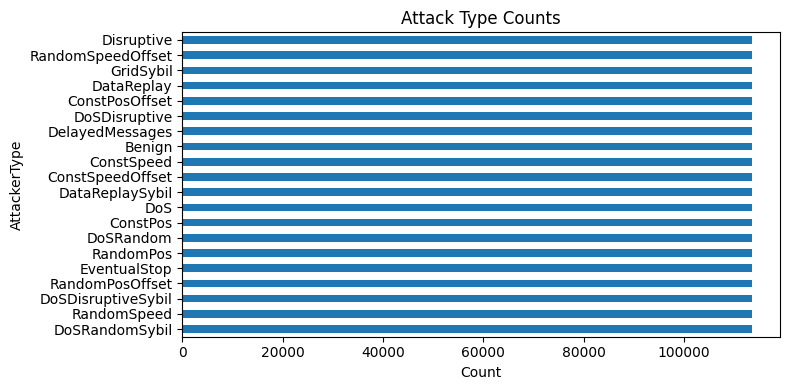

In [9]:
import matplotlib.pyplot as plt

attack_column_candidates = [
    "AttackerType",
    "AttackType",
    "attackType",
    "attacker_type",
    "attack_type",
    "Label",
]
attack_column = next(
    (
        column_name
        for column_name in attack_column_candidates
        if column_name in df.columns
    ),
    None,
)
if attack_column is None:
    raise KeyError("No attack/label column found in dataset")

attack_counts = df[attack_column].value_counts(dropna=False).sort_values()
print(attack_counts)

ax = attack_counts.plot(kind="barh", figsize=(8, 4))
ax.set_xlabel("Count")
ax.set_ylabel(attack_column)
ax.set_title("Attack Type Counts")
plt.tight_layout()
